In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
from google.colab import files

In [8]:
df=pd.read_csv('/content/Diwali Sales Data.csv', encoding='latin1')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [9]:
df.shape

(11251, 15)

In [10]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [11]:
df.head()


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [12]:
df.shape

(11251, 13)

In [13]:
df.isnull().sum()


,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [27]:
df.dropna(inplace=True)
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


In [37]:
df=pd.read_csv('/content/Diwali Sales Data.csv', encoding='latin1')
df.drop(['Status','unnamed1'],axis=1,inplace=True)
df.dropna(inplace=True)
df['Amount']=df['Amount'].astype('int')

In [39]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877


In [38]:
df['Amount'].dtypes

dtype('int64')

In [45]:
df[['Orders', 'Age', 'Amount']].describe()

,Orders,Age,Amount
count,11239.000000,11239.000000,11239.000000
mean,2.489634,35.410357,9453.610553
std,1.114967,12.753866,5222.355168
min,1.000000,12.000000,188.000000
25%,2.000000,27.000000,5443.000000
50%,2.000000,33.000000,8109.000000
75%,3.000000,43.000000,12675.000000
max,4.000000,92.000000,23952.000000


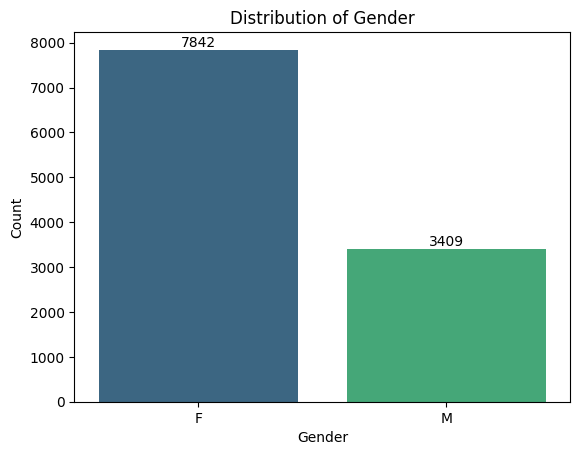

In [14]:
sns.countplot(x='Gender', data=df, palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

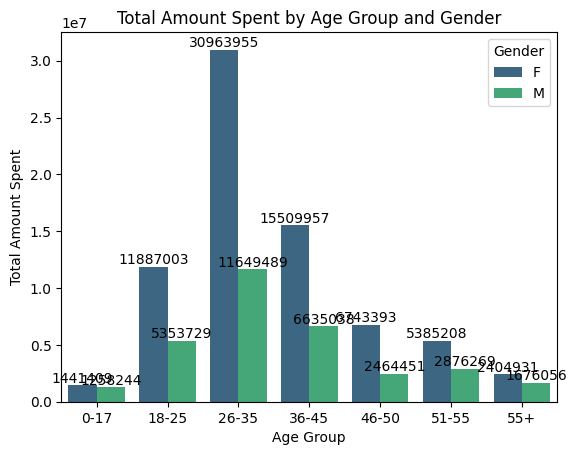

In [17]:
sales_age_gender = df.groupby(['Age Group', 'Gender'])['Amount'].sum().reset_index()
sns.barplot(data=sales_age_gender, x='Age Group', y='Amount', hue='Gender', palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars, fmt='%.0f')
plt.title('Total Amount Spent by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Total Amount Spent')
plt.show()

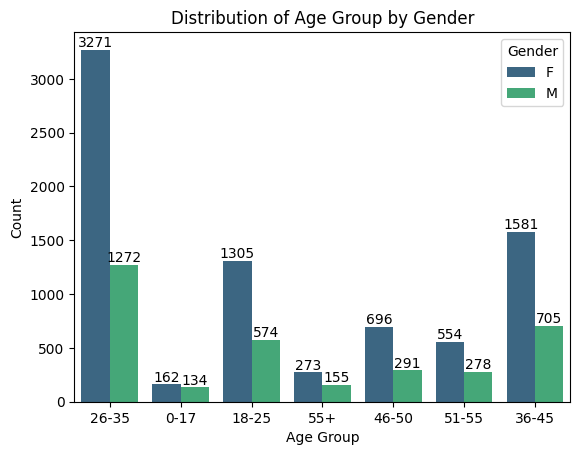

In [16]:
sns.countplot(data=df, x='Age Group', hue='Gender', palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars)
plt.title('Distribution of Age Group by Gender')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [18]:
sales_state = df.groupby('State')['Orders'].sum().sort_values(ascending=False).head(10)
print('Top 10 States by Orders:')
print(sales_state)

Top 10 States by Orders:
State
Uttar Pradesh       4813
Maharashtra         3811
Karnataka           3241
Delhi               2744
Madhya Pradesh      2259
Andhra Pradesh      2054
Himachal Pradesh    1568
Kerala              1137
Haryana             1109
Gujarat             1070
Name: Orders, dtype: int64


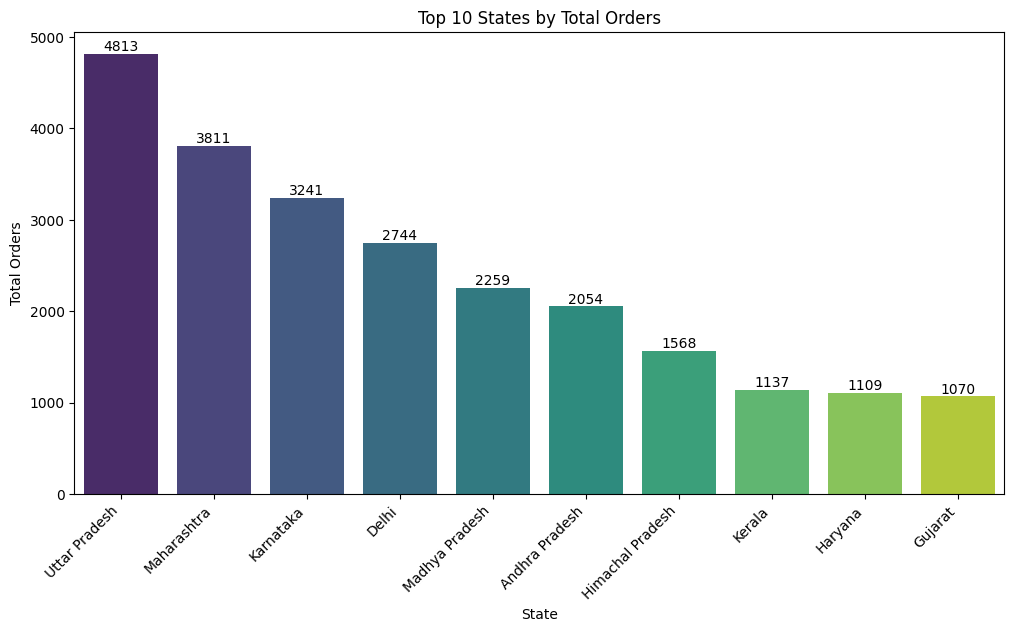

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x=sales_state.index, y=sales_state.values, palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars)
plt.title('Top 10 States by Total Orders')
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')
plt.show()

In [20]:
sales_amount_state = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)
print('Top 10 States by Amount:')
print(sales_amount_state)

Top 10 States by Amount:
State
Uttar Pradesh       19374968.00
Maharashtra         14427543.00
Karnataka           13523540.00
Delhi               11603819.45
Madhya Pradesh       8101142.00
Andhra Pradesh       8037146.99
Himachal Pradesh     4963368.00
Haryana              4220175.00
Bihar                4022757.00
Gujarat              3946082.00
Name: Amount, dtype: float64


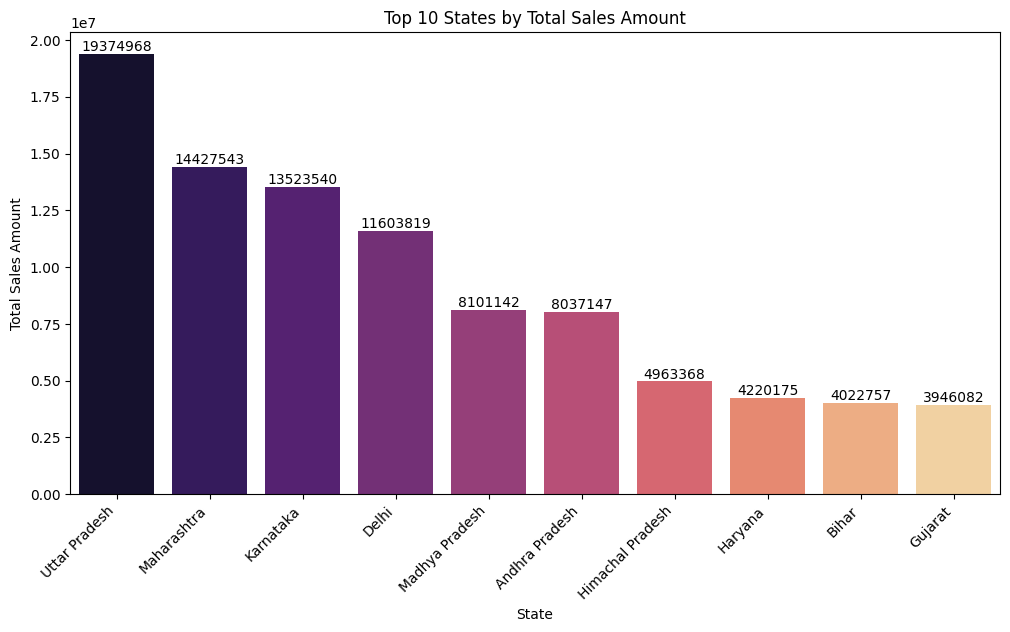

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(x=sales_amount_state.index, y=sales_amount_state.values, palette='magma')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars, fmt='%.0f')
plt.title('Top 10 States by Total Sales Amount')
plt.xlabel('State')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45, ha='right')
plt.show()

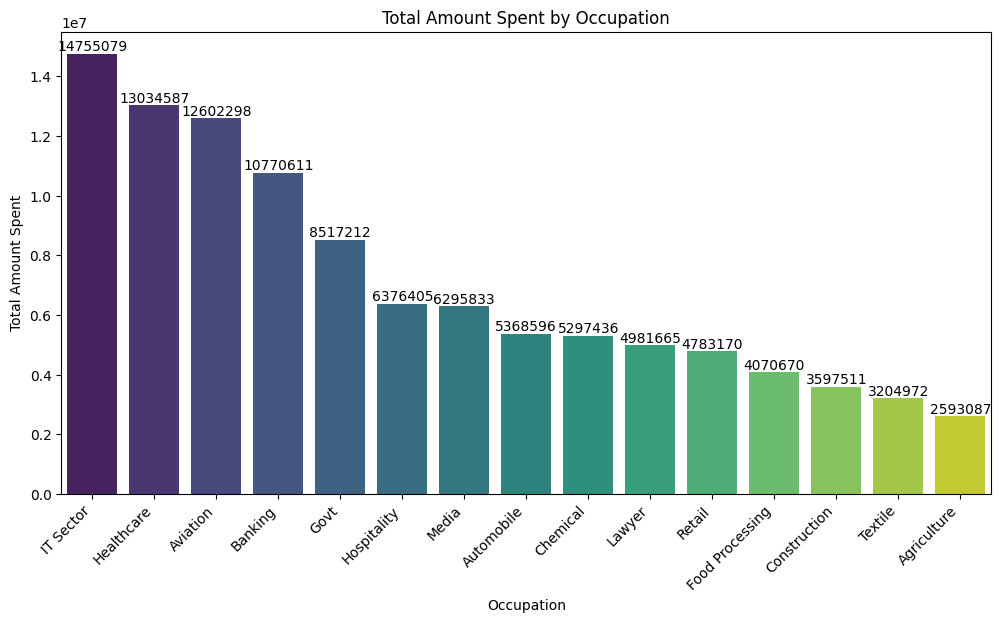

In [23]:
sales_occupation = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Occupation', y='Amount', data=sales_occupation, palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars, fmt='%.0f')
plt.title('Total Amount Spent by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.show()

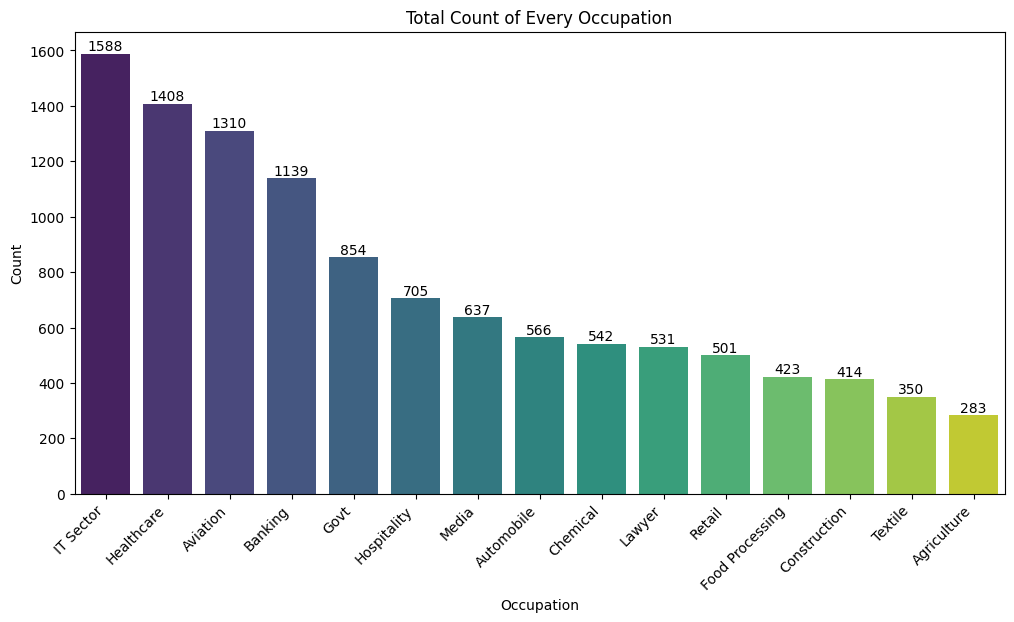

In [22]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Occupation', palette='viridis', order=df['Occupation'].value_counts().index)
for bars in plt.gca().containers:
    plt.gca().bar_label(bars)
plt.title('Total Count of Every Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [27]:
top_10_selling_products = df.groupby('Product_ID')['Orders'].sum().sort_values(ascending=False).head(10)
print('Top 10 Selling Product IDs by Orders:')
print(top_10_selling_products)

Top 10 Selling Product IDs by Orders:
Product_ID
P00265242    127
P00110942    116
P00237542     91
P00184942     82
P00114942     79
P00025442     79
P00117942     76
P00145042     76
P00044442     75
P00110842     74
Name: Orders, dtype: int64


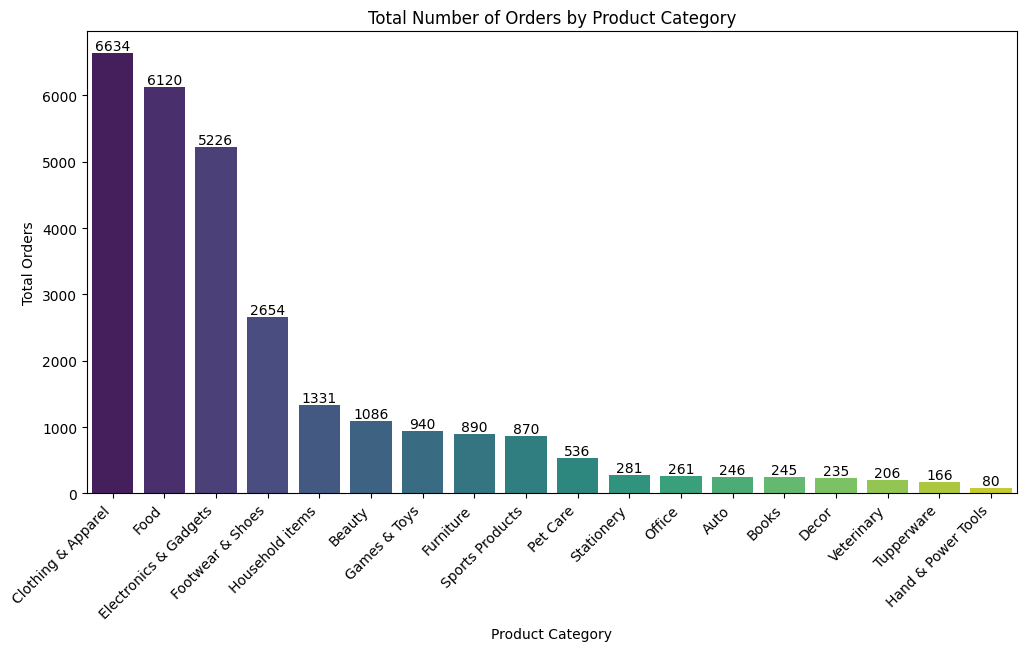

In [24]:
sales_product_category = df.groupby('Product_Category')['Orders'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Product_Category', y='Orders', data=sales_product_category, palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars, fmt='%.0f')
plt.title('Total Number of Orders by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')
plt.show()

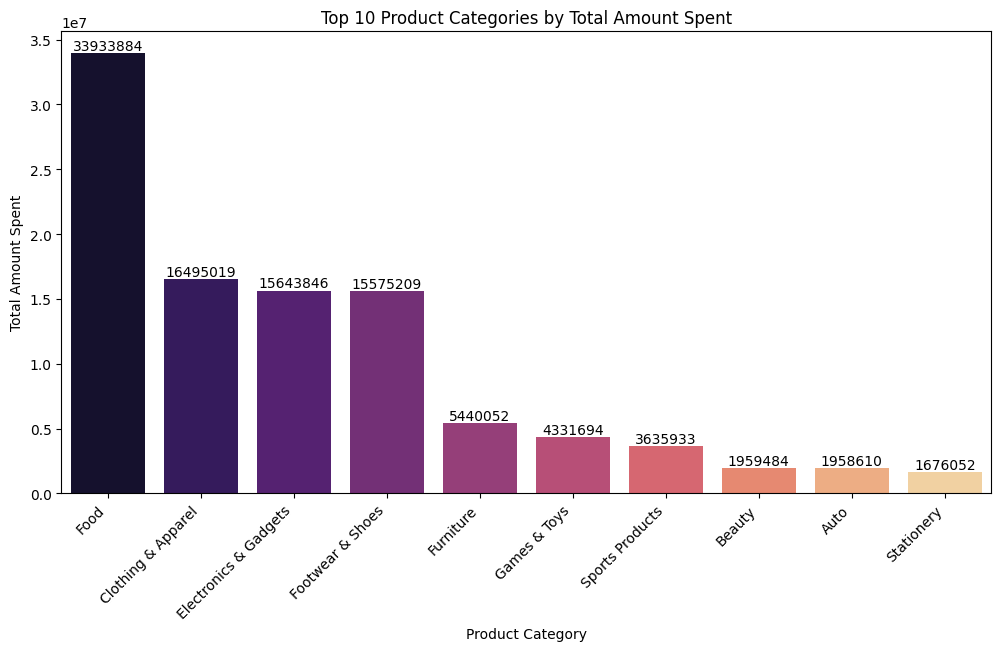

In [26]:
sales_product_category_amount = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Product_Category', y='Amount', data=sales_product_category_amount, palette='magma')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars, fmt='%.0f')
plt.title('Top 10 Product Categories by Total Amount Spent')
plt.xlabel('Product Category')
plt.ylabel('Total Amount Spent')
plt.xticks(rotation=45, ha='right')
plt.show()

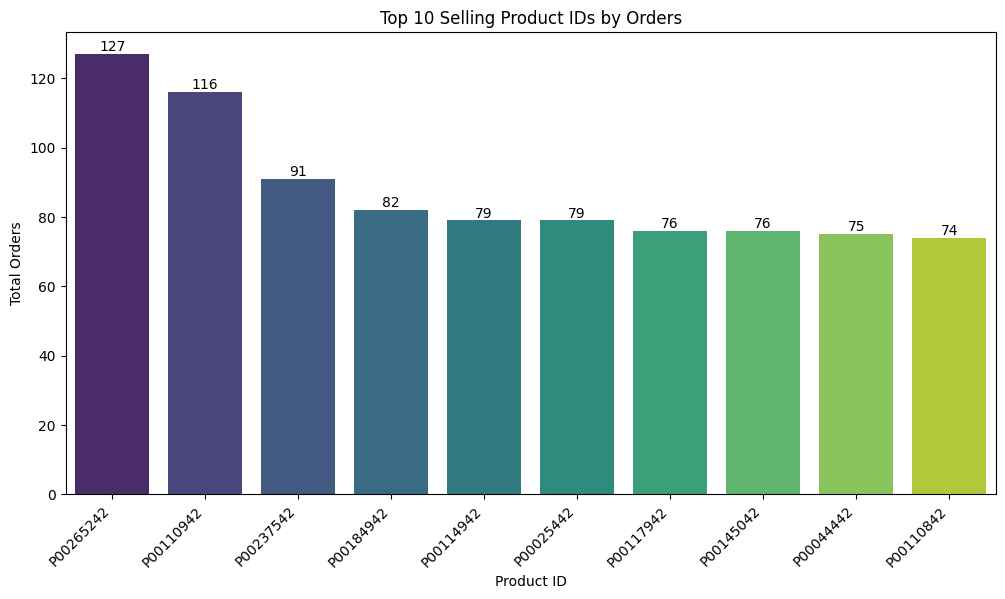

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_selling_products.index, y=top_10_selling_products.values, palette='viridis')
for bars in plt.gca().containers:
    plt.gca().bar_label(bars, fmt='%.0f')
plt.title('Top 10 Selling Product IDs by Orders')
plt.xlabel('Product ID')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')
plt.show()